# Innleverings-PDF
## IND320 -- Ass 1

## General

In this first part of the project I worked with both Jupyter Notebook and Streamlit to get a
basic dashboard up and running. In Jupyter Notebook I read the supplied CSV file with
Pandas, printed the contents in a structured way and created plots of both individual columns
and all columns together. I made sure to run all code cells so the results and figures are visible
when I export the notebook to PDF. I also added comments so the code is easier to understand
and follow if someone else were to continue my work.

For the Streamlit app I created four pages, with a home page, a data table page, a plot page
and an about page. The home page has a sidebar that lets you navigate to the other pages. On
the data table page the CSV file is shown together with a small line chart for each column for
the first month of the dataset. On the plot page it is possible to choose one column or all
columns from a drop down menu and also filter months with a slider. The app uses caching so
that the CSV file loads faster, and I added the CSV file into the repository so that it works
both locally and on Streamlit Cloud.

I struggled a lot with file formats in the beginning. I first worked only with ipynb files but
Streamlit does not accept those, so I had to make sure to keep the code in py files as well. I
also had problems when I tried to organize everything into folders, because Streamlit Cloud
and GitHub did not always find the files in the right place. In the end I fixed this by keeping
streamlit_app.py and utils.py in the root folder, and by using relative paths instead of absolute
ones for loading the CSV file. I also had to clean up the requirements.txt file so that only the
packages I really needed were listed. After these changes the deployment on Streamlit Cloud
finally worked.

I used AI tools like ChatGPT while working on the project. It helped me when I got stuck on
errors, for example with missing files, wrong imports and when the app failed to run in the
cloud. It also explained how to set up caching, how to structure the repository and how to read
the Streamlit error logs. I learned more about how to debug and organize a project like this.

My GitHub repository is available here: https://github.com/Sheikh20o3/IND320_1_Project

Streamlit app is available here: https://streamv2.streamlit.app/

### Read the supplied CSV file and Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess

# Load the dataset
df = pd.read_csv("/Users/a.h.sheikh/Desktop/IND320_Git_Job/IND320_1_Project/Innlevering og IPYNB/open-meteo-subset.csv")
df['time'] = pd.to_datetime(df['time'], errors='coerce')


### Visualisation

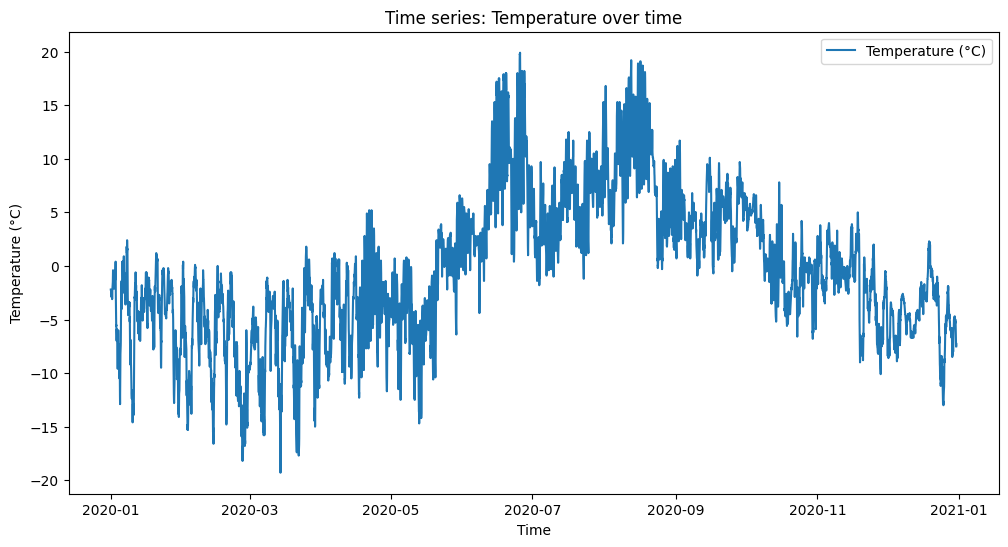

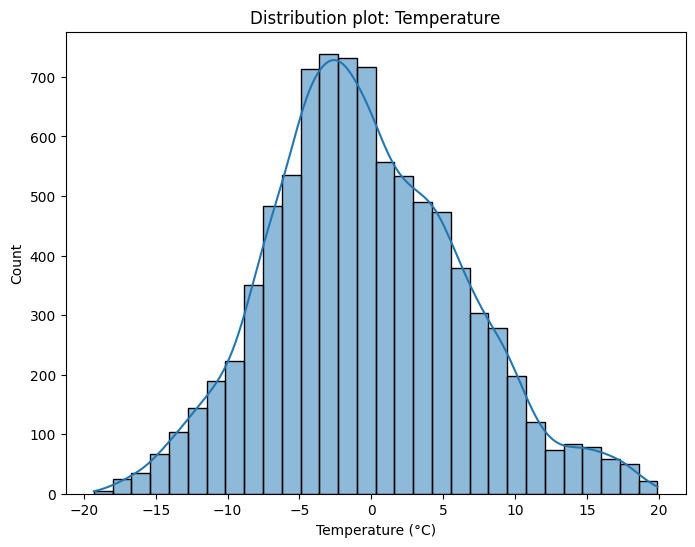

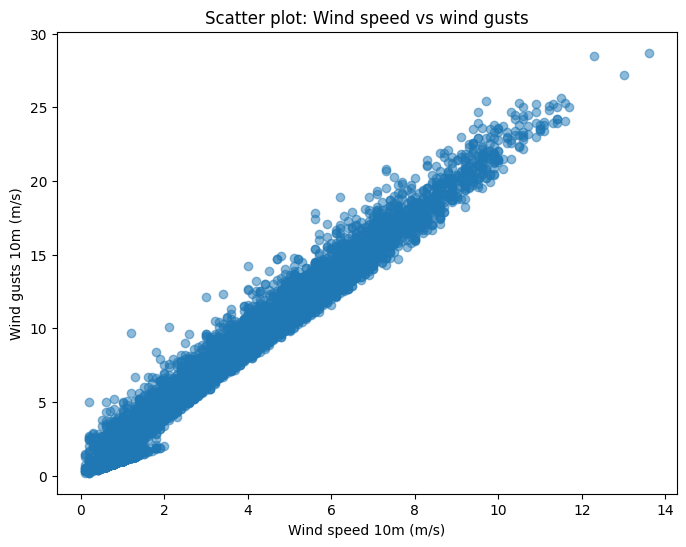

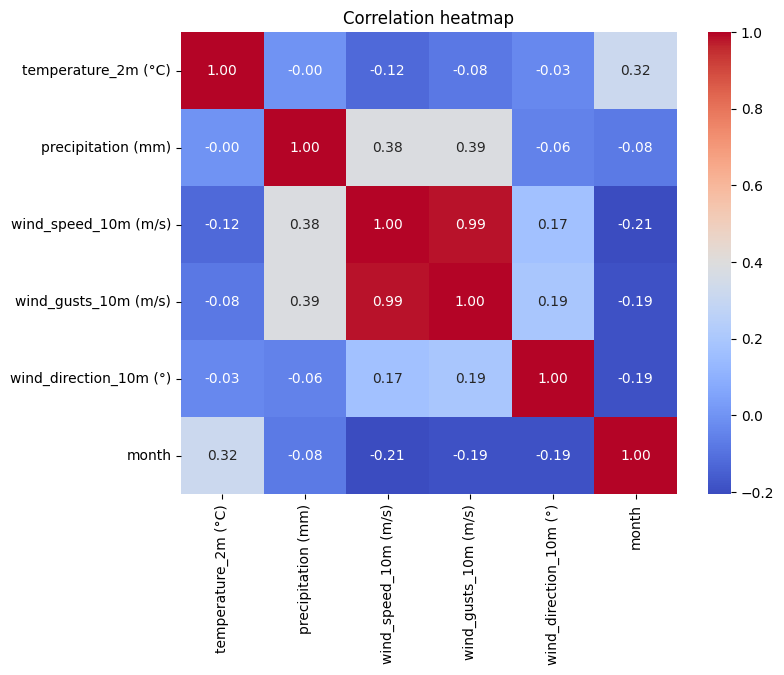

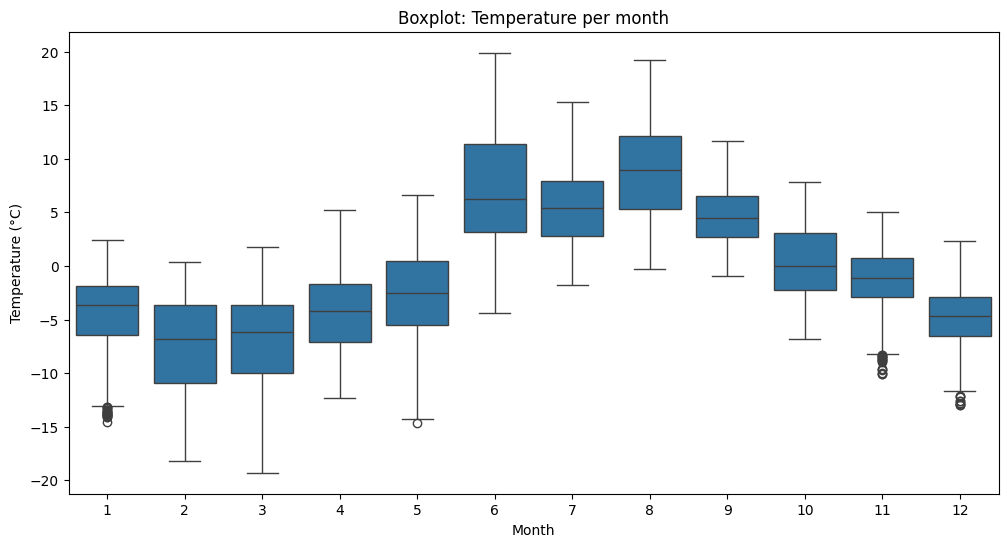

In [2]:

# Load the dataset
df = pd.read_csv("open-meteo-subset.csv")
df['time'] = pd.to_datetime(df['time'], errors='coerce')  # datetime format
df['month'] = df['time'].dt.month  # create a month column for grouping

# 1. Time series plot 
plt.figure(figsize=(12,6))
plt.plot(df['time'], df['temperature_2m (°C)'], label="Temperature (°C)")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Time series: Temperature over time")
plt.legend()
plt.show()

# Histogram (distribution of temperature)
plt.figure(figsize=(8,6))
sns.histplot(df['temperature_2m (°C)'], bins=30, kde=True)
plt.xlabel("Temperature (°C)")
plt.title("Distribution plot: Temperature")
plt.show()

# Scatter plot 
plt.figure(figsize=(8,6))
plt.scatter(df['wind_speed_10m (m/s)'], df['wind_gusts_10m (m/s)'], alpha=0.5)
plt.xlabel("Wind speed 10m (m/s)")
plt.ylabel("Wind gusts 10m (m/s)")
plt.title("Scatter plot: Wind speed vs wind gusts")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

# Boxplot of temperature per month
plt.figure(figsize=(12,6))
sns.boxplot(x='month', y='temperature_2m (°C)', data=df)
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Boxplot: Temperature per month")
plt.show()


### Plot each column separately.

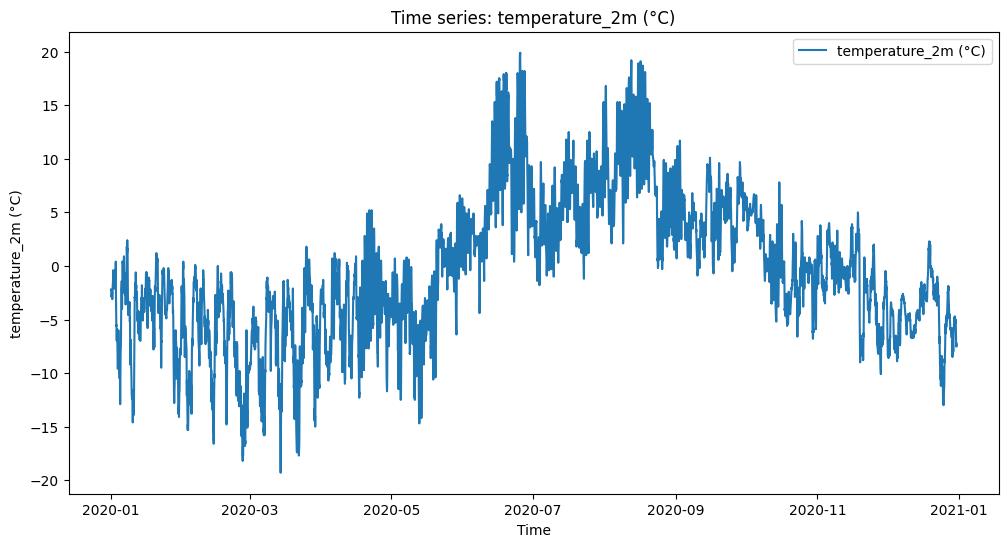

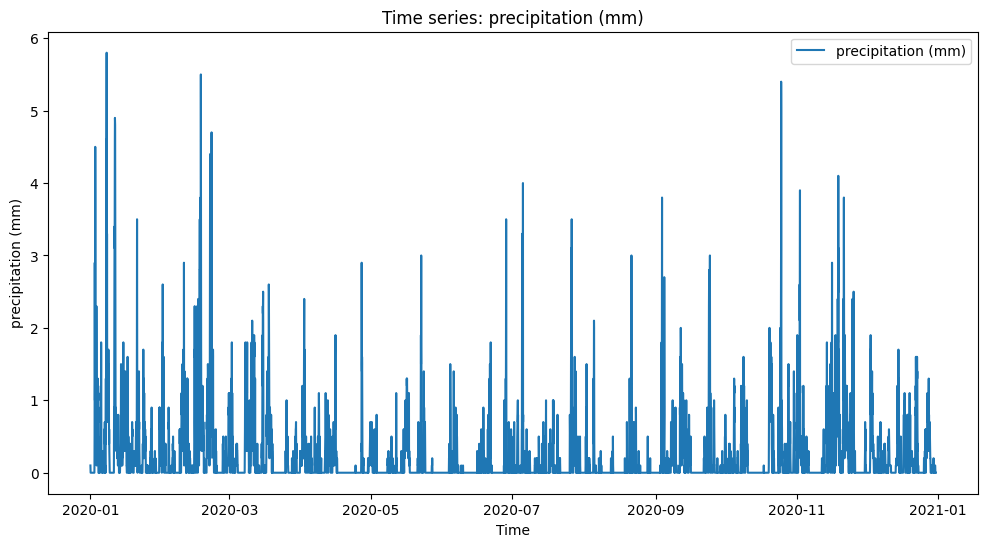

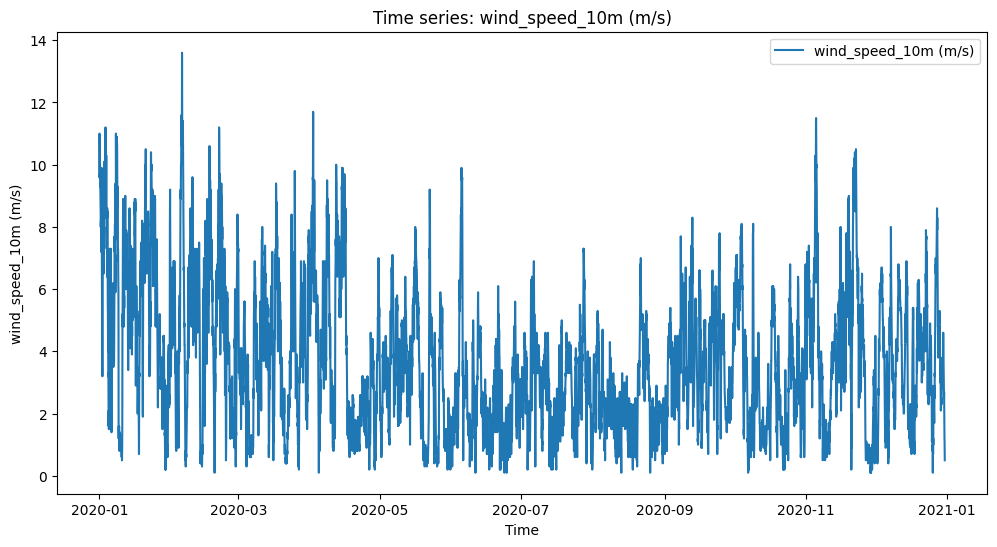

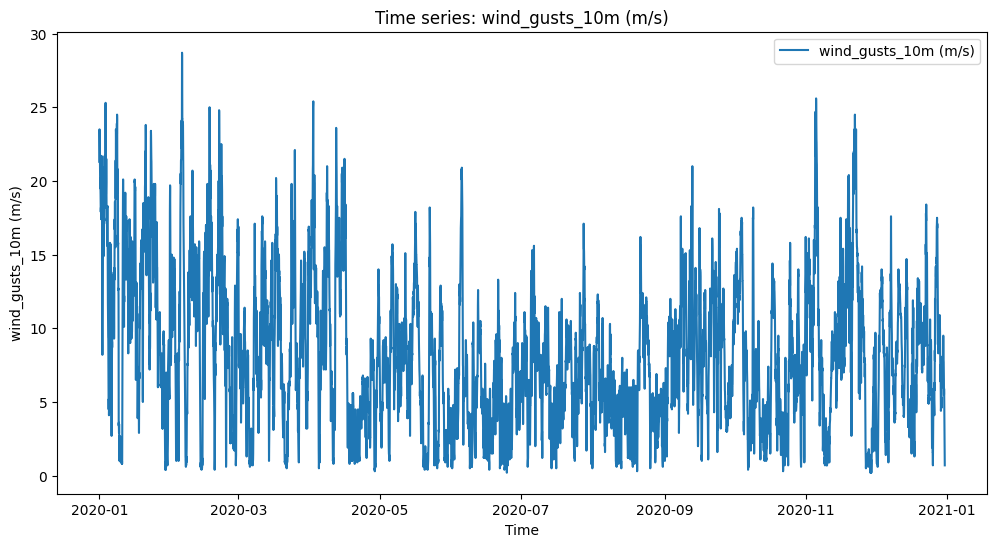

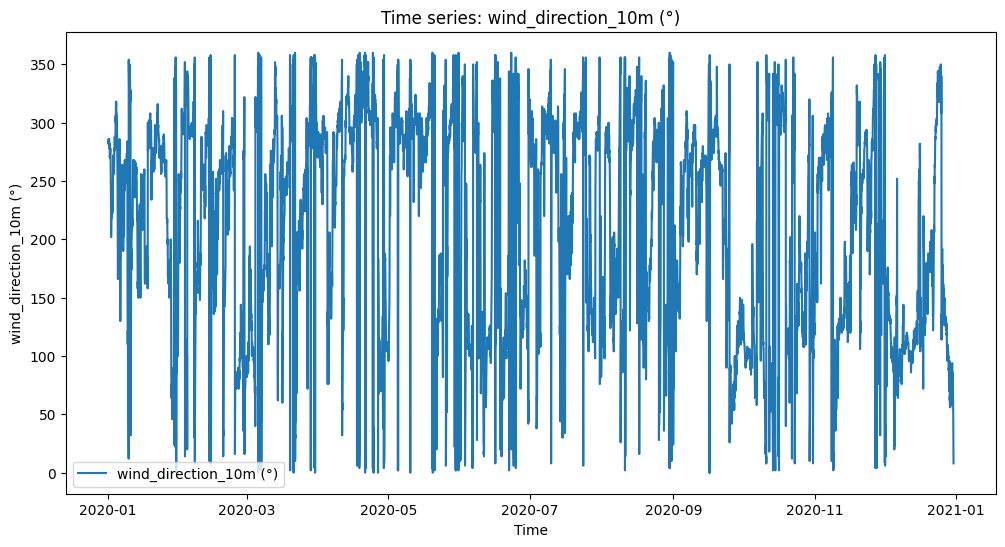

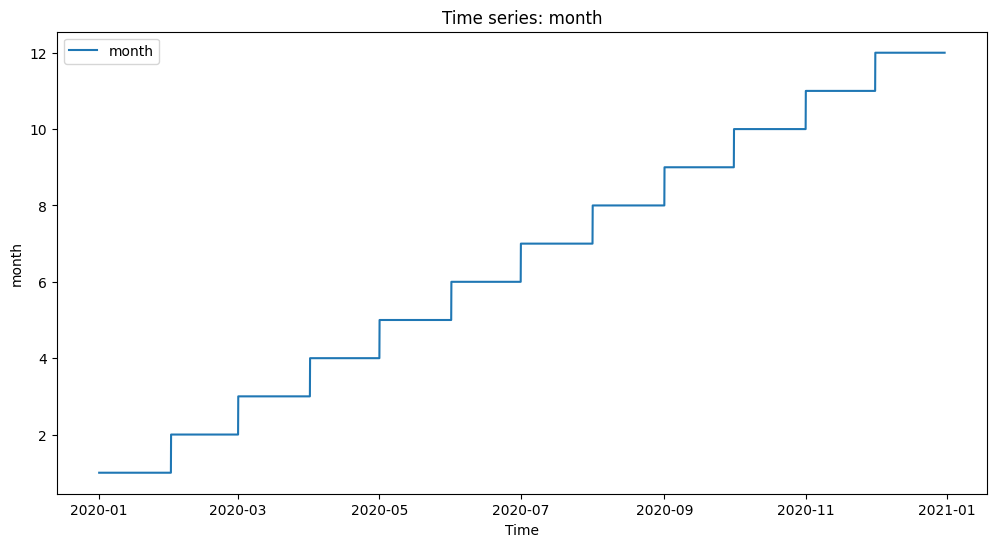

In [3]:
# Loop through all numeric columns and plot them separately
for col in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(12,6))
    plt.plot(df['time'], df[col], label=col)
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.title(f"Time series: {col}")
    plt.legend()
    plt.show()


### Reflection
When plotting each variable individually it quickly becomes clear that the scales are very different. Temperature ranges between about –20 and +20 degrees, precipitation is mostly small spikes that do not exceed a few millimeters, wind speed and gusts vary within a completely different range, and wind direction covers the full circle of 0 to 360 degrees. If these series were shown on the same axis the smaller values would be overshadowed and almost invisible. With each variable having its own figure it becomes natural to read the changes and patterns over time because every plot uses a scale that fits the data it shows. This way we can see the seasonal cycle of temperature, the irregular rainfall events, and the dynamics of wind without the distortions that would occur if everything was forced into a single graph.

### Plot all columns together
Doing it by using multiple y-axes

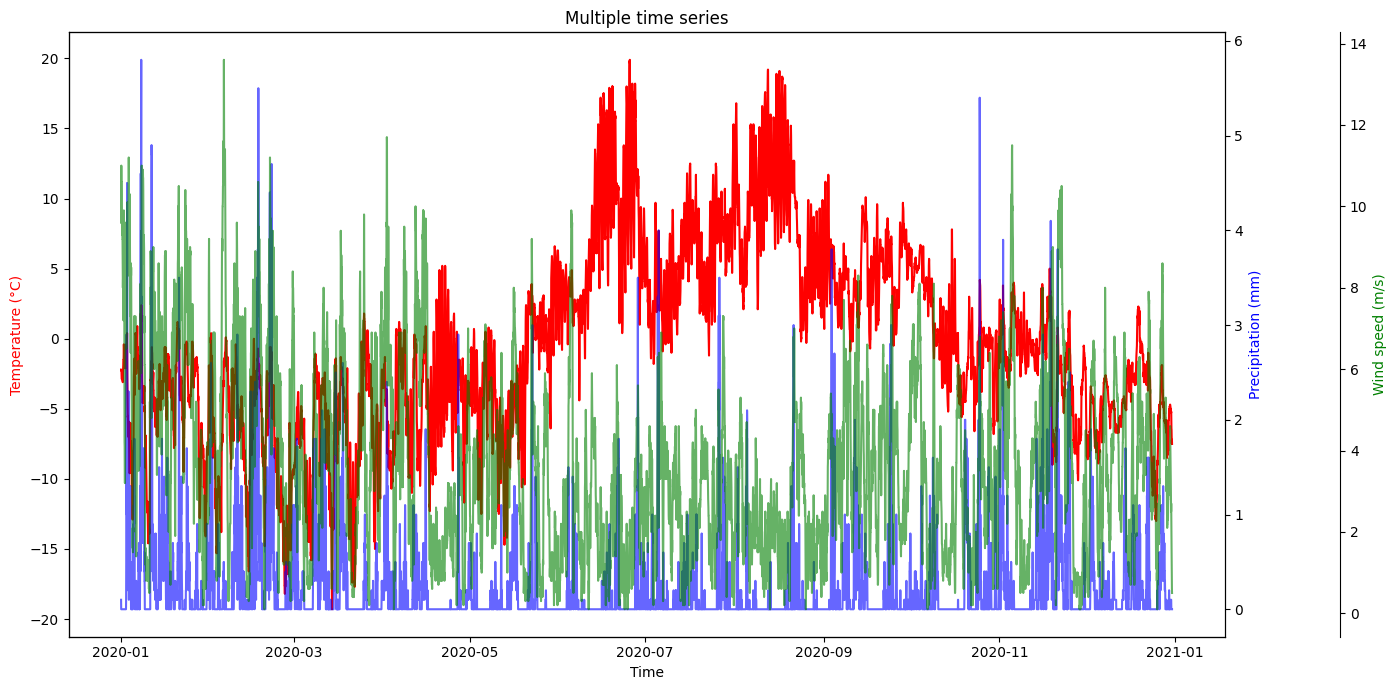

In [4]:
fig, ax1 = plt.subplots(figsize=(14,7))

# Temperature on left y-axis
ax1.plot(df['time'], df['temperature_2m (°C)'], 'r-', label="Temperature (°C)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature (°C)", color="r")

# Precipitation on right y-axis
ax2 = ax1.twinx()
ax2.plot(df['time'], df['precipitation (mm)'], 'b-', alpha=0.6, label="Precipitation (mm)")
ax2.set_ylabel("Precipitation (mm)", color="b")

# Wind speed on another axis (optional)
ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.1))  # shift to the right
ax3.plot(df['time'], df['wind_speed_10m (m/s)'], 'g-', alpha=0.6, label="Wind speed (m/s)")
ax3.set_ylabel("Wind speed (m/s)", color="g")

plt.title("Multiple time series")
fig.tight_layout()
plt.show()


### Reflection
When plotting all columns together is the challenge that the variables are measured on very different scales. Temperature is expressed in Celsius and ranges between –20 and +20. Where the precipitation is measured in millimeters and often not exceeds 6, The wind speed is measured in meters per second and reaches 14. The wind direction is in degrees from 0 to 360. I plotted all columns together using multiple y-axes. This approach preserves the original units of each variable and makes the figure easier to interpret. Here can I read the values of temperature, precipitation and wind speed. If all series were forced onto a single scale, the small variations in precipitation would disappear compared to the much larger ranges of wind direction or temperature. When each variable have its own axis, the differences become visible while still being displayed in the same figure. This makes the visualization easier to read, since it reflects the true magnitudes of the data rather than abstract normalized values. 

## Github log to show pull and push commands

In [5]:
import subprocess
import pandas as pd

# Run git log and capture output
result = subprocess.check_output(
    ["git", "log", "--pretty=format:%h|%an|%ad|%s", "--date=short"],
    text=True
)

# Split into lines and parse into DataFrame
rows = [line.split("|") for line in result.split("\n")]
df_log = pd.DataFrame(rows, columns=["Commit", "Author", "Date", "Message"])

df_log.head(20)


,Commit,Author,Date,Message
0,9ed89f5,A H Sheikh,2025-09-30,IND320: oppdaterer Streamlit + utils; notebook...
1,0f8fbc9,A H Sheikh,2025-09-30,"Added all plots in notebook, updated explanati..."
2,3451f44,A H Sheikh,2025-09-29,La til requirements.txt for Streamlit Cloud
3,c96c5b5,A H Sheikh,2025-09-28,La til commits_github.txt i Innlevering og IPYNB
4,8d648f4,A H Sheikh,2025-09-28,Updated notebooks to use %run utils.ipynb inst...
5,48b3fa0,A H Sheikh,2025-09-28,Fix requirements.txt for Streamlit Cloud
6,e400a3e,A H Sheikh,2025-09-28,Fix utils.py to use relative path for CSV
7,0f65672,A H Sheikh,2025-09-28,Added dataset CSV and restored pages folder fo...
8,6df0632,A H Sheikh,2025-09-28,Moved streamlit_app.py and utils.py back to ro...
9,675022a,A H Sheikh,2025-09-28,Moved all notebooks and utils.ipynb into same ...
